# <font size=6><b>Lec03. [실습] 영화 유사도

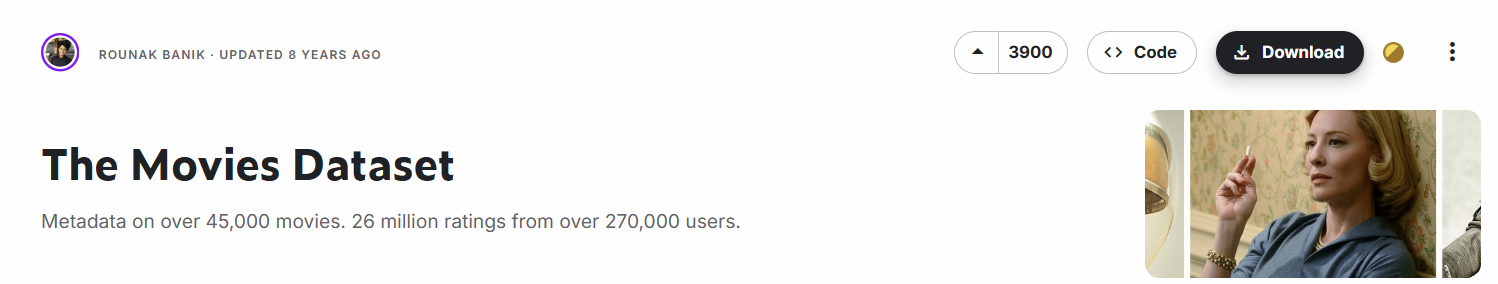
* https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

# ----------------------------------------------------------- 토큰화
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# ----------------------------------------------------------- 유사도
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

In [2]:
movie = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\LLM\movie\movies_metadata.csv", low_memory=False)
movie.head(1)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0


In [3]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

# <b>전처리 & 가공
* 결측제거 , 중복제거

In [4]:
movie.shape

(45466, 24)

In [5]:
print(movie.shape)
movie = movie.drop_duplicates(subset=['overview'])
print(movie.shape)

(45466, 24)
(44308, 24)


In [6]:
print(movie.shape)
movie  = movie.dropna(subset=['overview'] , axis=0)
print(movie.shape)

(44308, 24)
(44307, 24)


In [7]:
movie = movie[['title', 'overview']].head(20000)
movie.head(2)

,title,overview
0,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences."
1,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures."


# <b>유사도

## 불용어 사전 로드

In [8]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [9]:
stop_words_list = stopwords.words('english')
print('불용어 개수 :', len(stop_words_list))
print('불용어 5개 출력 :',stop_words_list[:5])

(198, ['a', 'about', 'above', 'after', 'again'])

## 토큰화

### [방법1] Tokenizer 토큰화 : 사전 인덱스 기반  

In [10]:
" ".join(['i','eat','cake'])

'i eat cake'

In [11]:
import re
def MY_STOPWORDS_DEF(text) : 
    text = text.lower()
    re_text = re.findall(r'\b[a-z]{2,}\b', text)
    re_stop_text = [word for word in re_text if word not in stop_words_list ]  #['i','eat','cake']
    return " ".join(re_stop_text)

In [12]:
MY_STOPWORDS_DEF("i like a cat and dog and i am are is have a notebook.")

'like cat dog notebook'

In [13]:
movie['overview'] = movie['overview'].apply(MY_STOPWORDS_DEF)
movie.head(1)

,title,overview
0,Toy Story,led woody andy toys live happily room andy birthday brings buzz lightyear onto scene afraid losing place andy heart woody plots buzz circumstances separate buzz woody owner duo eventually learns put aside differences


In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tk = Tokenizer()
tk.fit_on_texts(movie['overview'])                     #-------------------[1]문장/단어 자르기
#print( tk.word_index)                                 #-----------사전확인 : 단어인덱스
#print(tk.word_counts)                                 #-----------사전확인 : 단어빈도
res = tk.texts_to_sequences(movie['overview'])         #-------------------[2]임베딩(단어자르기->인코딩->리스트)
pad = pad_sequences(res,  padding='post')              #--------------------[3]패딩
print(pad.shape)
print(pad)

(20000, 121)
[[  405  3948  1451 ...     0     0     0]
 [ 2473  3616   423 ...     0     0     0]
 [    9   458 13995 ...     0     0     0]
 ...
 [ 1716  1731   114 ...     0     0     0]
 [13754  8749  3710 ...     0     0     0]
 [  597  2617   107 ...     0     0     0]]


### [방법2] TF-IDF 토큰화 - 카운트 기반
* TF-IDF(Term Frequency-Inverse Document Frequency)
* 단어빈도 + 단어가 나온 문서수의 역수

In [15]:
tfidf_vt = TfidfVectorizer( stop_words=stop_words_list , lowercase=True
                            , token_pattern=r'\b[a-z]{2,}\b')
res = tfidf_vt.fit_transform(movie['overview'])  #---------- 1D
#print(tfidf_vt.vocabulary_)

print(res.shape)
print(tfidf_vt.get_feature_names_out())

tfidf = pd.DataFrame(res.toarray(), columns=tfidf_vt.get_feature_names_out(), index=movie['title'])
print(tfidf.shape)
tfidf.head(1)

(20000, 46325)
['aa' 'aaa' 'aab' ... 'zyklus' 'zylberstein' 'zyto']
(20000, 46325)


,aa,aaa,aab,aalst,aames,aamir,aang,aarne,aaron,aarons,aasen,aashish,aba,abacco,aback,abaddon,abagnale,abalone,abandon,abandoned,abandoning,abandonment,abandons,abatcha,abates,abati,abba,abbas,abbass,abbe,abberline,abbess,abbey,abbie,abbot,abbott,abby,abc,abdel,abdelatif,abdelkader,abdicate,abdicated,abdicates,abdicating,abdication,abduct,abducted,abductee,abducting,...,zoo,zooey,zookeeper,zoolander,zoole,zoologic,zoological,zoologist,zoologists,zoology,zoom,zoos,zoosters,zoot,zootechnician,zopa,zoran,zorba,zords,zorg,zorin,zorina,zorn,zorns,zorro,zorteper,zostaje,zoya,zsa,zsolt,zu,zubin,zuckerberg,zuckerman,zuckermann,zula,zulu,zulus,zune,zurich,zus,zuzu,zwar,zweig,zwraca,zygadlo,zyklon,zyklus,zylberstein,zyto
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Toy Story,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 유사도 측정
* cosine_similarity

### [방법1] Tokenizer matrix 사용

In [16]:
idx_cos_matrix = cosine_similarity(pad , pad)

In [17]:
idx_cos_matrix.shape

(20000, 20000)

In [18]:
idx_cos_df = pd.DataFrame(idx_cos_matrix, index=movie['title'] , columns=movie['title'])
idx_cos_df.head()

title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II,Heat,Sabrina,Tom and Huck,Sudden Death,GoldenEye,The American President,Dracula: Dead and Loving It,Balto,Nixon,Cutthroat Island,Casino,Sense and Sensibility,Four Rooms,Ace Ventura: When Nature Calls,Money Train,Get Shorty,Copycat,Assassins,Powder,Leaving Las Vegas,Othello,Now and Then,Persuasion,The City of Lost Children,Shanghai Triad,Dangerous Minds,Twelve Monkeys,Babe,Carrington,Dead Man Walking,Across the Sea of Time,It Takes Two,Clueless,"Cry, the Beloved Country",Richard III,Dead Presidents,Restoration,Mortal Kombat,To Die For,How To Make An American Quilt,Se7en,Pocahontas,When Night Is Falling,The Usual Suspects,Guardian Angel,...,The Central Park Five,The Collection,The Cherry Orchard: Blossoming,FDR: American Badass!,All Superheroes Must Die,Jean Renoir: Part One - From La Belle Époque to World War II,Booker's Place: A Mississippi Story,Girl Walk // All Day,Las Acacias,Just Ask My Children,Never Too Young to Die,Remember the Daze,Waiting for Lightning,Yesterday's Enemy,Young People,The Villain,Soldiers of Fortune,Rurouni Kenshin,Les Misérables,Extracted,Stevie,Mansome,Les Misérables,Les Miserables,The Big Street,The True Meaning of Christmas Specials,Great Escape: The Untold Story,Kenji Mizoguchi: The Life of a Film Director,Cornelis,Promised Land,Neo Ned,Offender,Confessions of a Window Cleaner,The Man Who Haunted Himself,Dakota Skye,A Demon in My View,The Immaculate Conception of Little Dizzle,Judas Kiss,Confessions of a Pop Performer,Private Romeo,Role/Play,I Know What I Saw,The Sweeney,English Vinglish,Fish Story,Comedy Central Roast of Bob Saget,Tiny Toon Adventures: How I Spent My Vacation,Trapped in the Closet: Chapters 1-12,The Sea of Grass,The Visitors
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Toy Story,1.000000,0.298499,0.195828,0.227616,0.302651,0.433025,0.194161,0.135163,0.179636,0.661508,0.434232,0.248172,0.114325,0.364974,0.245854,0.101074,0.124589,0.312968,0.410440,0.123189,0.229222,0.259433,0.233340,0.210849,0.379515,0.261156,0.188600,0.261384,0.228854,0.776756,0.307070,0.130662,0.495955,0.197207,0.202304,0.116623,0.198347,0.334843,0.117625,0.076391,0.564731,0.155826,0.306740,0.167279,0.211415,0.259760,0.122076,0.164900,0.566606,0.290297,...,0.171369,0.295209,0.570422,0.318588,0.232625,0.087392,0.164969,0.091284,0.165027,0.838745,0.199872,0.249608,0.204922,0.444233,0.146574,0.206762,0.102353,0.265818,0.215524,0.395955,0.089948,0.246173,0.111509,0.325333,0.303109,0.174571,0.431776,0.192706,0.153241,0.382054,0.320265,0.074749,0.385599,0.195999,0.125991,0.089980,0.154027,0.157165,0.196321,0.254191,0.213937,0.136904,0.180077,0.231774,0.216474,0.053239,0.119932,0.132337,0.160173,0.096075
Jumanji,0.298499,1.000000,0.186473,0.140010,0.130691,0.400718,0.198304,0.277602,0.207568,0.124141,0.133950,0.087951,0.110968,0.170630,0.257843,0.123565,0.075998,0.105751,0.200239,0.117391,0.302641,0.124301,0.137410,0.227344,0.195961,0.312217,0.237013,0.244662,0.200928,0.157080,0.184013,0.258562,0.217661,0.280961,0.127248,0.347069,0.211132,0.178816,0.098763,0.043811,0.216564,0.197429,0.361953,0.114560,0.208063,0.226647,0.399546,0.307683,0.714746,0.351649,...,0.333054,0.354918,0.469208,0.119784,0.265037,0.071806,0.077758,0.100274,0.105426,0.157869,0.172274,0.213872,0.026668,0.120643,0.223374,0.176803,0.091960,0.191385,0.220545,0.296331,0.123038,0.345219,0.085730,0.276460,0.128098,0.101379,0.256246,0.152649,0.220748,0.215608,0.372946,0.060674,0.314312,0.546577,0.227722,0.080640,0.275418,0.195003,0.182703,0.222511,0.200958,0.360257,0.221867,0.201948,0.333651,0.150031,0.191133,0.074974,0.222834,0.141166
Grumpier Old Men,0.195828,0.186473,1.000000,0.270744,0.578728,0.250722,0.432547,0.512211,0.223193,0.076628,0.420137,0.293299,0.171658,0.442244,0.332655,0.176935,0.575098,0.061423,0.388857,0.118876,0.248019,0.023702,0.316770,0.424840,0.210054,0.232283,0.329289,0.277631,0.095616,0.

### [방법2] TF-IDF matrix 사용

In [19]:
tfidf_cos_matrix = cosine_similarity(tfidf , tfidf)

In [20]:
tfidf_cos_matrix.shape

(20000, 20000)

In [21]:
tfidf_cos_df = pd.DataFrame(tfidf_cos_matrix, index=movie['title'] , columns=movie['title'])
tfidf_cos_df.head()

title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II,Heat,Sabrina,Tom and Huck,Sudden Death,GoldenEye,The American President,Dracula: Dead and Loving It,Balto,Nixon,Cutthroat Island,Casino,Sense and Sensibility,Four Rooms,Ace Ventura: When Nature Calls,Money Train,Get Shorty,Copycat,Assassins,Powder,Leaving Las Vegas,Othello,Now and Then,Persuasion,The City of Lost Children,Shanghai Triad,Dangerous Minds,Twelve Monkeys,Babe,Carrington,Dead Man Walking,Across the Sea of Time,It Takes Two,Clueless,"Cry, the Beloved Country",Richard III,Dead Presidents,Restoration,Mortal Kombat,To Die For,How To Make An American Quilt,Se7en,Pocahontas,When Night Is Falling,The Usual Suspects,Guardian Angel,...,The Central Park Five,The Collection,The Cherry Orchard: Blossoming,FDR: American Badass!,All Superheroes Must Die,Jean Renoir: Part One - From La Belle Époque to World War II,Booker's Place: A Mississippi Story,Girl Walk // All Day,Las Acacias,Just Ask My Children,Never Too Young to Die,Remember the Daze,Waiting for Lightning,Yesterday's Enemy,Young People,The Villain,Soldiers of Fortune,Rurouni Kenshin,Les Misérables,Extracted,Stevie,Mansome,Les Misérables,Les Miserables,The Big Street,The True Meaning of Christmas Specials,Great Escape: The Untold Story,Kenji Mizoguchi: The Life of a Film Director,Cornelis,Promised Land,Neo Ned,Offender,Confessions of a Window Cleaner,The Man Who Haunted Himself,Dakota Skye,A Demon in My View,The Immaculate Conception of Little Dizzle,Judas Kiss,Confessions of a Pop Performer,Private Romeo,Role/Play,I Know What I Saw,The Sweeney,English Vinglish,Fish Story,Comedy Central Roast of Bob Saget,Tiny Toon Adventures: How I Spent My Vacation,Trapped in the Closet: Chapters 1-12,The Sea of Grass,The Visitors
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Toy Story,1.000000,0.015725,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.038808,0.000000,0.0,0.009857,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.019401,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.006156,0.000000,0.0,0.009187,0.000000,0.000000,0.000000,0.013431,0.009672,...,0.000000,0.000000,0.008172,0.016985,0.0,0.0,0.000000,0.000000,0.013079,0.000000,0.000000,0.010917,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.011532,0.000000,0.005859,0.000000,0.000000,0.000000,0.0,0.0,0.017505,0.0,0.000000,0.0,0.000000,0.0,0.029387,0.035371,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0,0.000000,0.010749,0.024329,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
Jumanji,0.015725,1.000000,0.050043,0.008327,0.000000,0.049552,0.000000,0.000000,0.106791,0.0,0.007561,0.0,0.0,0.008092,0.009411,0.0,0.000000,0.027841,0.006970,0.0,0.000000,0.0,0.005968,0.000000,0.0,0.024617,0.025422,0.006409,0.0,0.00000,0.000000,0.049756,0.005575,0.004239,0.00000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.033942,0.0,0.000000,0.018211,0.008123,0.000000,0.016367,0.005009,...,0.006509,0.015055,0.005733,0.008067,0.0,0.0,0.000000,0.007132,0.000000,0.010276,0.005881,0.000000,0.000000,0.007474,0.000000,0.0,0.000000,0.000000,0.005486,0.061270,0.004412,0.005164,0.004505,0.008994,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.007313,0.014776,0.02409,0.000000,0.000000,0.04294,0.0,0.006594,0.000000,0.008292,0.007769,0.000000,0.000000,0.000000,0.0,0.005952
Grumpier Old Men,0.000000,0.050043,1.000000,0.024114,0.025468,0.000000,0.000000,0.006421,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.018369,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.011722,0.0,0.01073,0.000000,0.006698,0.006678,0.000000,0.00000,0.005384,0.0,0.0,0.0,0.0,0.000000,0.000000,0.007362,0.0,0.000000,0.015356,0.016508,0.016927,0.000000,0.000000,...,0.000000,0.000000,0.011452,0.000000,0.0,0.0,0.009604,0.000000,0.000000,0.000000,0.000000,0.008906,0.000000,0.00000

# <b>overview 유사 영화 Top-N

### [방법1] Tokenizer matrix 사용

In [22]:
idx_cos_df.loc['Toy Story'].sort_values(ascending=False)[0:6]   

title
Toy Story                                       1.000000
Bread and Chocolate                             0.881687
Body Parts                                      0.870169
Truly Human                                     0.859748
The Invisible War                               0.855226
Harry Potter and the Deathly Hallows: Part 1    0.854878
Name: Toy Story, dtype: float64

In [23]:
movie[movie['title']=="Toy Story"]['overview']

0    led woody andy toys live happily room andy birthday brings buzz lightyear onto scene afraid losing place andy heart woody plots buzz circumstances separate buzz woody owner duo eventually learns put aside differences
Name: overview, dtype: object

In [24]:
movie[movie['title']=="Bread and Chocolate"]['overview']

607    italian immigrant tries become member swiss society fails waiter even chicken plucker becomes involved shady wealthy character tries hide italian identity refuses give matter awful situation
Name: overview, dtype: object

### [방법2] TF-IDF matrix 사용

In [25]:
tfidf_cos_df.loc['Toy Story'].sort_values(ascending=False)[0:6]   

title
Toy Story                 1.000000
Toy Story 3               0.517314
Toy Story 2               0.456898
The 40 Year Old Virgin    0.271807
The Champ                 0.198247
Rebel Without a Cause     0.178497
Name: Toy Story, dtype: float64

In [26]:
movie[movie['title']=="Toy Story 3"]['overview']

15348    woody buzz rest andy toys played years andy go college gang find accidentally left nefarious day care center toys must band together escape return home andy
Name: overview, dtype: object

Toy Story 3 : 우디와 버즈, 그리고 앤디의 다른 장난감들은 오랫동안 함께 놀아왔다. 하지만 앤디가 대학에 가게 되면서 상황이 바뀐다. 장난감들은 우연히 사악한 어린이집에 남겨지게 되고, 그곳에서 탈출해 다시 앤디의 집으로 돌아가기 위해 힘을 합쳐야 한다. 

Toy Story : 우디, 앤디의 장난감들은 방에서 행복하게 살아간다. 하지만 앤디의 생일에 버즈 라이트이어가 등장하면서 상황이 달라진다. 앤디의 사랑을 빼앗길까 두려워한 우디는 버즈를 제거하려고 계획을 세운다. 그러나 예상치 못한 사건으로 우디와 버즈는 주인과 떨어지게 되고, 결국 두 사람은 서로의 차이를 내려놓고 협력하는 법을 배우게 된다. <br>

문장1과 문장2가 유사해?
<br>
| 단계    | 문장1         | 문장2           |
| ----- | ----------- | ------------- |
| 초기 상태 | 장난감들과 함께 생활 | 장난감들이 행복하게 생활 |
| 사건 발생 | 앤디가 대학 감    | 버즈 등장         |
| 갈등    | 어린이집에 갇힘    | 질투/경쟁         |
| 해결    | 협력해서 탈출     | 협력하게 됨        |


In [27]:
tfidf_cos_df.loc['The Dark Knight Rises'].sort_values(ascending=False)[0:6]   

title
The Dark Knight Rises         1.000000
The Dark Knight               0.318306
Batman Returns                0.297672
Batman Forever                0.297581
Batman: Under the Red Hood    0.281158
Batman                        0.271772
Name: The Dark Knight Rises, dtype: float64